# Chapter 6 Tutorial: Precision and Accuracy of Measurements

This notebook is a step-by-step tutorial for the main ideas in Chapter 6:

1. Measurement process and measurement population
2. Precision, imprecision, and standard deviation
3. Accuracy, reference values, and bias
4. Standard error of the mean
5. Probability intervals
6. Confidence intervals
7. Student's *t*
8. Tolerance intervals
9. Accuracy testing with a known reference value
10. Factors that affect precision and accuracy

The examples use simple measurement and benchmark-style data. The goal is not just to compute formulas, but to build the right mental model.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

rng = np.random.default_rng(42)

## 1. Measurement process → population of measurements

A measurement is not just a number. It comes from a **process** applied to a **specific system** under **specific conditions**.

A useful model:

```text
measurement process + system + conditions  →  population of possible measurements
```

For example, “disk write speed” is underspecified. You need workload, cache/warmup state, queue depth, VM shape, disk backend, host conditions, and so on.

In the simulation below, we create two different populations for the “same” benchmark:

- cold runs
- warmed-up runs

The command might look similar, but the measurement populations differ.

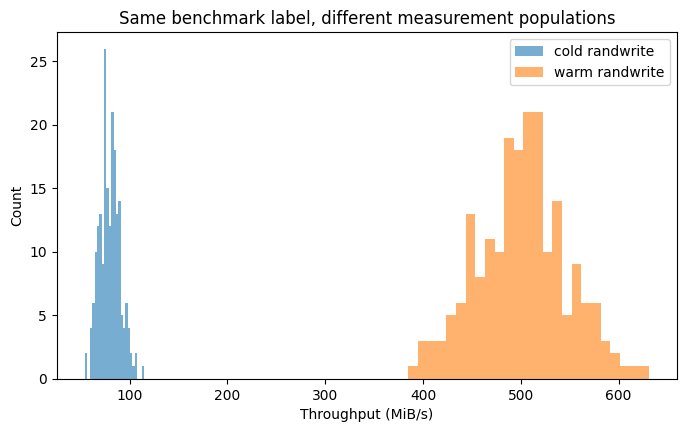

,condition,sample_mean,sample_sd
0,cold,79.634591,10.583195
1,warm,500.903493,45.877719


In [2]:
cold = rng.normal(loc=80, scale=12, size=200)     # MiB/s
warm = rng.normal(loc=500, scale=45, size=200)    # MiB/s

plt.figure(figsize=(8, 4.5))
plt.hist(cold, bins=25, alpha=0.6, label="cold randwrite")
plt.hist(warm, bins=25, alpha=0.6, label="warm randwrite")
plt.xlabel("Throughput (MiB/s)")
plt.ylabel("Count")
plt.title("Same benchmark label, different measurement populations")
plt.legend()
plt.show()

pd.DataFrame({
    "condition": ["cold", "warm"],
    "sample_mean": [cold.mean(), warm.mean()],
    "sample_sd": [cold.std(ddof=1), warm.std(ddof=1)]
})

### Thinking model

Before computing anything, ask:

```text
What exact process generated these numbers?
What exact system was measured?
Were all observations drawn from the same population?
```

If the answer is no, combining the numbers may hide the real structure.

## 2. Precision: scatter of repeated measurements

Precision is about **repeatability**.

A precise measurement process gives repeated results close to each other. An imprecise process gives scattered results.

Precision does **not** require the measurements to be correct. A scale can always read 2 kg too high and still be precise.

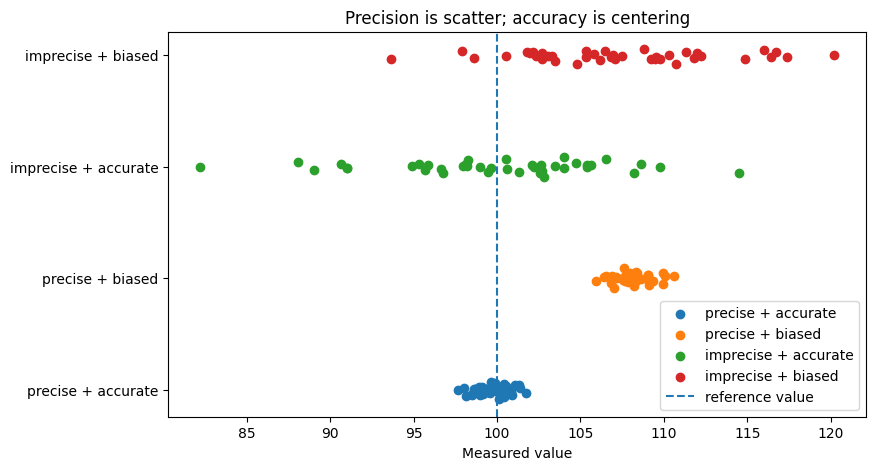

,case,mean,sd,bias_vs_reference
0,precise + accurate,99.785635,0.975581,-0.214365
1,precise + biased,108.148159,1.031553,8.148159
2,imprecise + accurate,99.887033,6.475637,-0.112967
3,imprecise + biased,107.328830,5.810335,7.328830


In [3]:
true_value = 100.0

precise_accurate = rng.normal(loc=true_value, scale=1.0, size=40)
precise_biased = rng.normal(loc=true_value + 8, scale=1.0, size=40)
imprecise_accurate = rng.normal(loc=true_value, scale=6.0, size=40)
imprecise_biased = rng.normal(loc=true_value + 8, scale=6.0, size=40)

datasets = {
    "precise + accurate": precise_accurate,
    "precise + biased": precise_biased,
    "imprecise + accurate": imprecise_accurate,
    "imprecise + biased": imprecise_biased,
}

plt.figure(figsize=(9, 5))
for i, (label, values) in enumerate(datasets.items(), start=1):
    y = np.full_like(values, i, dtype=float) + rng.normal(0, 0.035, len(values))
    plt.scatter(values, y, label=label)

plt.axvline(true_value, linestyle="--", label="reference value")
plt.yticks(range(1, 5), list(datasets.keys()))
plt.xlabel("Measured value")
plt.title("Precision is scatter; accuracy is centering")
plt.legend(loc="lower right")
plt.show()

summary = pd.DataFrame({
    "case": list(datasets.keys()),
    "mean": [v.mean() for v in datasets.values()],
    "sd": [v.std(ddof=1) for v in datasets.values()],
    "bias_vs_reference": [v.mean() - true_value for v in datasets.values()],
})
summary

### Thinking model

```text
precision = width of the measurement cloud
accuracy  = location of the cloud center relative to the reference value
bias      = mean(measurements) - reference value
```

## 3. Standard deviation vs. standard error

These are often confused.

### Standard deviation

Standard deviation describes the scatter of **individual observations**.

### Standard error of the mean

Standard error describes the uncertainty of the **sample mean**.

If independent observations have sample standard deviation `s` and sample size `N`:

$$
SE(\bar{x}) = \frac{s}{\sqrt{N}}
$$

Increasing `N` makes the mean more stable, but slowly: to cut standard error by 4×, you need 16× as many observations.

In [4]:
def summarize_sample(x):
    n = len(x)
    s = np.std(x, ddof=1)
    se = s / math.sqrt(n)
    return pd.Series({"N": n, "mean": np.mean(x), "standard_deviation": s, "standard_error": se})

sample = rng.normal(loc=500, scale=50, size=25)
summarize_sample(sample)

N                      25.000000
mean                  490.024128
standard_deviation     56.305141
standard_error         11.261028
dtype: float64

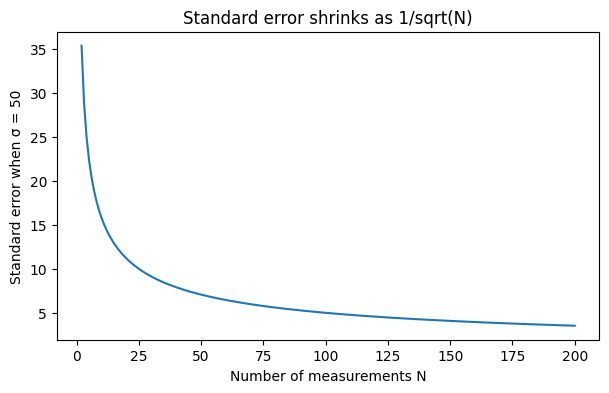

In [5]:
Ns = np.arange(2, 201)
sigma = 50
se_values = sigma / np.sqrt(Ns)

plt.figure(figsize=(7, 4))
plt.plot(Ns, se_values)
plt.xlabel("Number of measurements N")
plt.ylabel("Standard error when σ = 50")
plt.title("Standard error shrinks as 1/sqrt(N)")
plt.show()

### Example interpretation

If benchmark throughput has:

```text
mean = 500 MiB/s
standard deviation = 50 MiB/s
N = 25
standard error = 10 MiB/s
```

Then:

- individual runs vary by roughly tens of MiB/s
- the estimated mean is much more stable
- more runs reduce random uncertainty in the mean
- more runs do **not** remove systematic bias

## 4. Range as a quick estimate of standard deviation

For small samples, Chapter 6 discusses estimating standard deviation from the range:

$$
\hat{\sigma} \approx \frac{R}{d_2}
$$

where:

$$
R = \max(x_i) - \min(x_i)
$$

As a rough mental shortcut for small samples:

$$
d_2 \approx \sqrt{N}
$$

so:

$$
\hat{\sigma} \approx \frac{R}{\sqrt{N}}
$$

This is less precise than using the sample standard deviation, but it is useful for quick estimates.

In [6]:
small_sample = np.array([98, 101, 100, 103, 99])
R = small_sample.max() - small_sample.min()
n = len(small_sample)

quick_sd = R / math.sqrt(n)
actual_sd = small_sample.std(ddof=1)
quick_se = R / n
actual_se = actual_sd / math.sqrt(n)

pd.DataFrame({
    "quantity": ["range", "quick sd ≈ range/sqrt(N)", "actual sample sd", "quick se ≈ range/N", "actual se"],
    "value": [R, quick_sd, actual_sd, quick_se, actual_se]
})

,quantity,value
0,range,5.000000
1,quick sd ≈ range/sqrt(N),2.236068
2,actual sample sd,1.923538
3,quick se ≈ range/N,1.000000
4,actual se,0.860233


### Thinking model

Range is the “field estimate.” Standard deviation is the more formal estimate.

Range is especially useful when you have very few numbers and need a quick sense of scatter.

## 5. Probability intervals: where individual observations fall

A probability interval is about future **individual observations**, not the mean.

For a normal population with known mean `μ` and standard deviation `σ`:

$$
\mu - 1.96\sigma < X < \mu + 1.96\sigma
$$

contains about 95% of individual observations.

This is wider than a confidence interval for the mean, because individual observations vary more than averages.

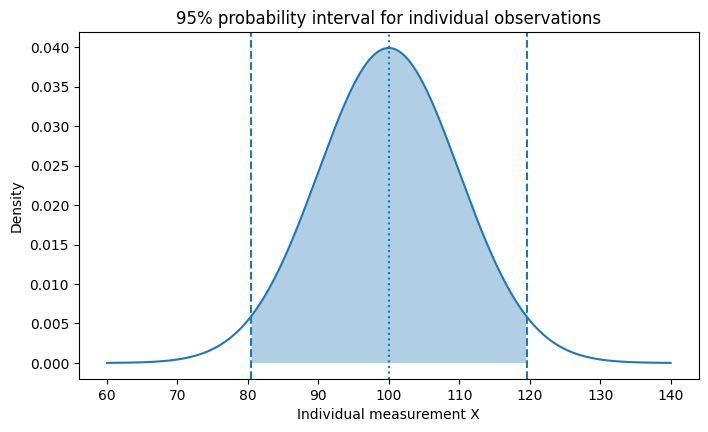

(80.4, 119.6)

In [7]:
mu = 100
sigma = 10
x_grid = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)

if SCIPY_AVAILABLE:
    y_grid = stats.norm.pdf(x_grid, mu, sigma)
else:
    y_grid = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*((x_grid-mu)/sigma)**2)

lower = mu - 1.96*sigma
upper = mu + 1.96*sigma

plt.figure(figsize=(8, 4.5))
plt.plot(x_grid, y_grid)
plt.fill_between(x_grid, y_grid, where=(x_grid >= lower) & (x_grid <= upper), alpha=0.35)
plt.axvline(lower, linestyle="--")
plt.axvline(upper, linestyle="--")
plt.axvline(mu, linestyle=":")
plt.xlabel("Individual measurement X")
plt.ylabel("Density")
plt.title("95% probability interval for individual observations")
plt.show()

lower, upper

### Thinking model

Probability interval answers:

```text
Where will individual future values tend to land?
```

It does not answer:

```text
Where is the true mean?
```

## 6. Confidence intervals: uncertainty about the mean

A confidence interval is about the unknown population mean.

When standard deviation is estimated from the sample, use Student's *t*:

$$
\bar{x} \pm t \frac{s}{\sqrt{N}}
$$

For a 95% two-sided confidence interval with `N = 25`, the degrees of freedom are:

$$
DF = N - 1 = 24
$$

The exact multiplier is approximately:

$$
t_{0.975,24} \approx 2.064
$$

For rough mental calculation, people often use `t ≈ 2`.

In [11]:
x = sample
n = len(x)
mean = x.mean()
s = x.std(ddof=1)
se = s / math.sqrt(n)
df = n - 1

if SCIPY_AVAILABLE:
    tcrit = stats.t.ppf(0.975, df)
else:
    tcrit = 2.064

ci_lower = mean - tcrit * se
ci_upper = mean + tcrit * se

pd.DataFrame({
    "quantity": ["N", "DF", "mean", "sample sd", "standard error", "t critical", "CI lower", "CI upper"],
    "value": [n, df, mean, s, se, tcrit, ci_lower, ci_upper]
})

,quantity,value
0,N,25.000000
1,DF,24.000000
2,mean,490.024128
3,sample sd,56.305141
4,standard error,11.261028
5,t critical,2.063899
6,CI lower,466.782508
7,CI upper,513.265748


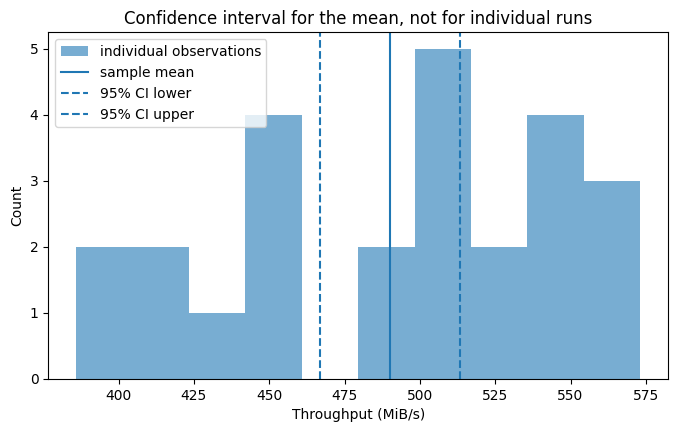

In [12]:
plt.figure(figsize=(8, 4.5))
plt.hist(x, bins=10, alpha=0.6, label="individual observations")
plt.axvline(mean, linestyle="-", label="sample mean")
plt.axvline(ci_lower, linestyle="--", label="95% CI lower")
plt.axvline(ci_upper, linestyle="--", label="95% CI upper")
plt.xlabel("Throughput (MiB/s)")
plt.ylabel("Count")
plt.title("Confidence interval for the mean, not for individual runs")
plt.legend()
plt.show()

### Simulation: what 95% confidence means

A 95% confidence interval means:

```text
If we repeated this whole procedure many times,
about 95% of the intervals constructed this way would contain the true mean.
```

The interval is random because it depends on the sample.

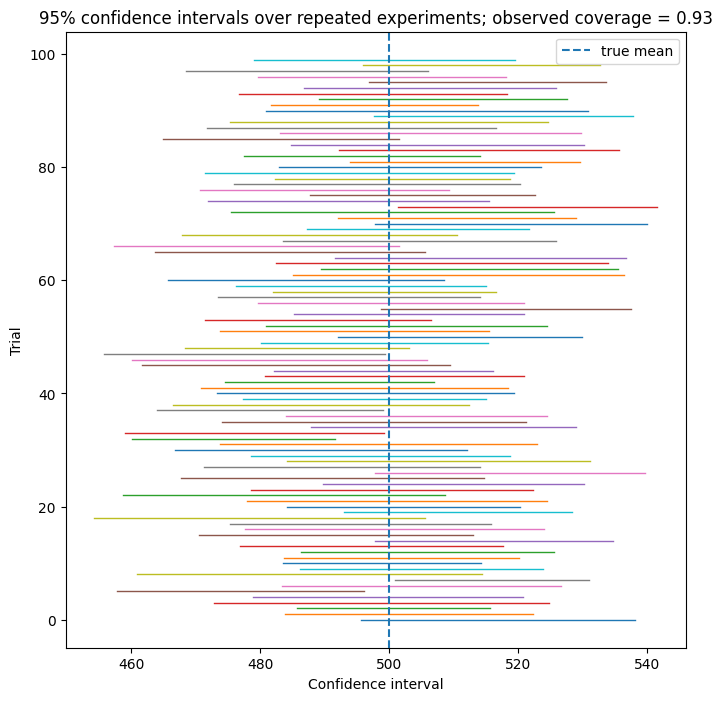

np.float64(0.93)

In [10]:
true_mu = 500
true_sigma = 50
n = 25
trials = 100

intervals = []
contains = []

for _ in range(trials):
    xs = rng.normal(true_mu, true_sigma, size=n)
    xbar = xs.mean()
    s = xs.std(ddof=1)
    se = s / math.sqrt(n)
    df = n - 1
    if SCIPY_AVAILABLE:
        tcrit = stats.t.ppf(0.975, df)
    else:
        tcrit = 2.064
    lo, hi = xbar - tcrit * se, xbar + tcrit * se
    intervals.append((lo, hi))
    contains.append(lo <= true_mu <= hi)

coverage = np.mean(contains)

plt.figure(figsize=(8, 8))
for i, ((lo, hi), ok) in enumerate(zip(intervals, contains)):
    plt.plot([lo, hi], [i, i], linewidth=1)
plt.axvline(true_mu, linestyle="--", label="true mean")
plt.xlabel("Confidence interval")
plt.ylabel("Trial")
plt.title(f"95% confidence intervals over repeated experiments; observed coverage = {coverage:.2f}")
plt.legend()
plt.show()

coverage

## 7. Student's *t*: why the multiplier changes

When `σ` is unknown, the sample standard deviation `s` is itself uncertain.

Student's *t* accounts for this extra uncertainty. With small samples, the *t* distribution has heavier tails, so the multiplier is larger.

As sample size increases, Student's *t* approaches the standard normal multiplier `1.96` for a 95% two-sided interval.

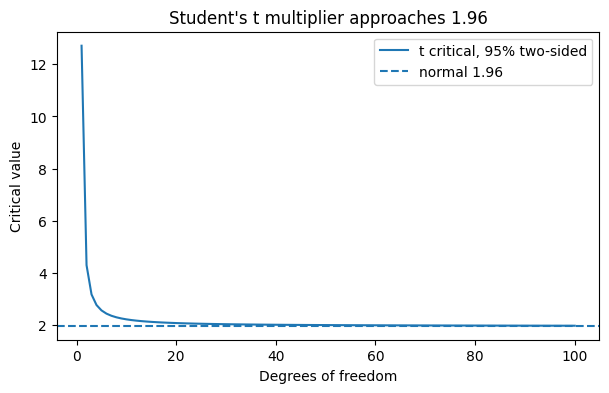

,DF,t_0.975
0,1,12.706205
1,2,4.302653
2,5,2.570582
3,10,2.228139
4,20,2.085963
5,24,2.063899
6,30,2.042272
7,100,1.983972


In [13]:
dfs = np.arange(1, 101)
if SCIPY_AVAILABLE:
    tcrit_values = stats.t.ppf(0.975, dfs)
else:
    # Approximation adequate for visualization if scipy unavailable.
    tcrit_values = 1.96 + 2.5 / dfs

plt.figure(figsize=(7, 4))
plt.plot(dfs, tcrit_values, label="t critical, 95% two-sided")
plt.axhline(1.96, linestyle="--", label="normal 1.96")
plt.xlabel("Degrees of freedom")
plt.ylabel("Critical value")
plt.title("Student's t multiplier approaches 1.96")
plt.legend()
plt.show()

dfs_to_show = [1, 2, 5, 10, 20, 24, 30, 100]
pd.DataFrame({
    "DF": dfs_to_show,
    "t_0.975": [stats.t.ppf(0.975, df) if SCIPY_AVAILABLE else np.nan for df in dfs_to_show]
})

### Thinking model

Student's *t* says:

```text
estimated effect / estimated standard error
```

When the denominator is estimated from little data, be more conservative.

## 8. Comparing two means

Often we care about a difference:

```text
new method - old method
```

If two sample means are independent, the standard error of the difference is:

$$
SE(\bar{x} - \bar{y}) =
\sqrt{\frac{s_x^2}{N_x} + \frac{s_y^2}{N_y}}
$$

A confidence interval for the difference tells us whether the expected difference is plausibly positive, negative, or near zero.

In [14]:
old = rng.normal(loc=40, scale=4, size=12)  # seconds
new = rng.normal(loc=34, scale=4, size=12)  # seconds

mean_diff = old.mean() - new.mean()  # positive means improvement in seconds
se_diff = math.sqrt(old.var(ddof=1)/len(old) + new.var(ddof=1)/len(new))

# Welch-Satterthwaite degrees of freedom
sx2, sy2 = old.var(ddof=1), new.var(ddof=1)
nx, ny = len(old), len(new)
df_welch = (sx2/nx + sy2/ny)**2 / ((sx2/nx)**2/(nx-1) + (sy2/ny)**2/(ny-1))

if SCIPY_AVAILABLE:
    tcrit = stats.t.ppf(0.975, df_welch)
else:
    tcrit = 2.1

lo = mean_diff - tcrit * se_diff
hi = mean_diff + tcrit * se_diff

pd.DataFrame({
    "quantity": ["old mean", "new mean", "estimated improvement", "SE difference", "Welch DF", "t critical", "CI lower", "CI upper"],
    "value": [old.mean(), new.mean(), mean_diff, se_diff, df_welch, tcrit, lo, hi]
})

,quantity,value
0,old mean,39.730415
1,new mean,33.397092
2,estimated improvement,6.333323
3,SE difference,1.690396
4,Welch DF,20.223079
5,t critical,2.084489
6,CI lower,2.809711
7,CI upper,9.856934


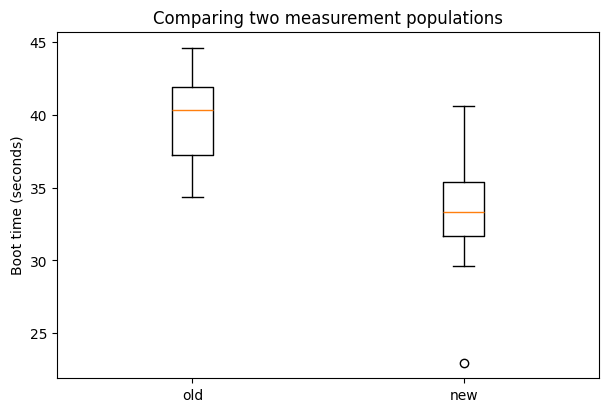

In [15]:
plt.figure(figsize=(7, 4.5))
plt.boxplot([old, new], tick_labels=["old", "new"])
plt.ylabel("Boot time (seconds)")
plt.title("Comparing two measurement populations")
plt.show()

### Thinking model

For comparisons, systematic bias may cancel **if** it affects both groups equally.

Example: if a stopwatch is always 0.2 seconds slow, the difference between old and new methods may still be useful.

But if the measurement procedure biases one group differently, the comparison is biased.

## 9. Tolerance intervals: covering a fraction of the population

A confidence interval estimates where the population mean is.

A tolerance interval estimates a range that contains at least some fraction of individual population values.

Example statement:

```text
With 95% confidence, at least 90% of future values are inside this interval.
```

This is useful for quality control and performance SLO-style thinking.

For a normal population, an approximate two-sided tolerance interval has the form:

$$
\bar{x} \pm k s
$$

The value of `k` depends on sample size, desired confidence level, desired population coverage, and normality assumptions.

Below we use a simulation-based approximation for `k`.

In [16]:
def estimate_tolerance_k(n, coverage=0.90, confidence=0.95, sims=100_000, seed=123):
    # Estimate k for a two-sided normal tolerance interval xbar +/- k*s.
    #
    # The simulation finds k such that, for samples of size n from N(0,1),
    # the interval contains at least `coverage` of the true population with
    # probability approximately `confidence`.
    local_rng = np.random.default_rng(seed)
    samples = local_rng.normal(size=(sims, n))
    means = samples.mean(axis=1)
    sds = samples.std(axis=1, ddof=1)

    if not SCIPY_AVAILABLE:
        raise RuntimeError("This cell needs scipy for the normal CDF.")

    # For interval [mean - k*s, mean + k*s], true normal coverage is:
    # CDF(mean + k*s) - CDF(mean - k*s), because true distribution is N(0,1).
    lo, hi = 0.0, 10.0
    for _ in range(50):
        mid = (lo + hi) / 2
        coverages = stats.norm.cdf(means + mid*sds) - stats.norm.cdf(means - mid*sds)
        prob = np.mean(coverages >= coverage)
        if prob >= confidence:
            hi = mid
        else:
            lo = mid
    return hi

n = 30
if SCIPY_AVAILABLE:
    k = estimate_tolerance_k(n, coverage=0.90, confidence=0.95, sims=50_000)
else:
    k = 2.14

leather_like = rng.normal(loc=416, scale=35, size=n)
xbar = leather_like.mean()
s = leather_like.std(ddof=1)
tol_lo = xbar - k*s
tol_hi = xbar + k*s

pd.DataFrame({
    "quantity": ["N", "mean", "sd", "k", "tolerance lower", "tolerance upper"],
    "value": [n, xbar, s, k, tol_lo, tol_hi]
})

,quantity,value
0,N,30.000000
1,mean,411.243430
2,sd,33.056867
3,k,2.147786
4,tolerance lower,340.244342
5,tolerance upper,482.242519


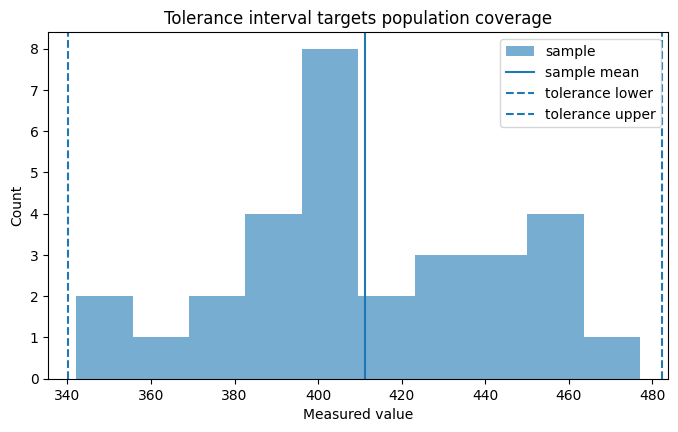

In [17]:
plt.figure(figsize=(8, 4.5))
plt.hist(leather_like, bins=10, alpha=0.6, label="sample")
plt.axvline(xbar, linestyle="-", label="sample mean")
plt.axvline(tol_lo, linestyle="--", label="tolerance lower")
plt.axvline(tol_hi, linestyle="--", label="tolerance upper")
plt.xlabel("Measured value")
plt.ylabel("Count")
plt.title("Tolerance interval targets population coverage")
plt.legend()
plt.show()

### Confidence interval vs. tolerance interval

Use this rule:

```text
confidence interval:
    Where is the population mean?

tolerance interval:
    What range covers most individual population values?
```

For performance work:

- confidence interval: uncertainty in mean throughput
- tolerance interval: range covering most future benchmark runs
- SLO-style question: fraction of requests/runs below or above a threshold

## 10. Measuring accuracy with a known reference value

If you have a reference value `R`, you can estimate bias:

$$
\hat{B} = \bar{x} - R
$$

Then form a confidence interval for the bias:

$$
\hat{B} \pm t \frac{s}{\sqrt{N}}
$$

If the interval excludes zero, there is evidence of bias.

In [18]:
R = 3.179  # known reference value, mg

# Similar to the book's beryllium example
beryllium_found = np.array([3.167, 3.177, 3.177, 3.169, 3.173, 3.177, 3.177, 3.177, 3.171, 3.169])

n = len(beryllium_found)
xbar = beryllium_found.mean()
s = beryllium_found.std(ddof=1)
se = s / math.sqrt(n)
bias_hat = xbar - R
df = n - 1

if SCIPY_AVAILABLE:
    tcrit = stats.t.ppf(0.975, df)
else:
    tcrit = 2.262

bias_lo = bias_hat - tcrit * se
bias_hi = bias_hat + tcrit * se

pd.DataFrame({
    "quantity": ["reference R", "mean found", "estimated bias", "sample sd", "SE of bias", "DF", "t critical", "bias CI lower", "bias CI upper"],
    "value": [R, xbar, bias_hat, s, se, df, tcrit, bias_lo, bias_hi]
})

,quantity,value
0,reference R,3.179000
1,mean found,3.173400
2,estimated bias,-0.005600
3,sample sd,0.004088
4,SE of bias,0.001293
5,DF,9.000000
6,t critical,2.262157
7,bias CI lower,-0.008524
8,bias CI upper,-0.002676


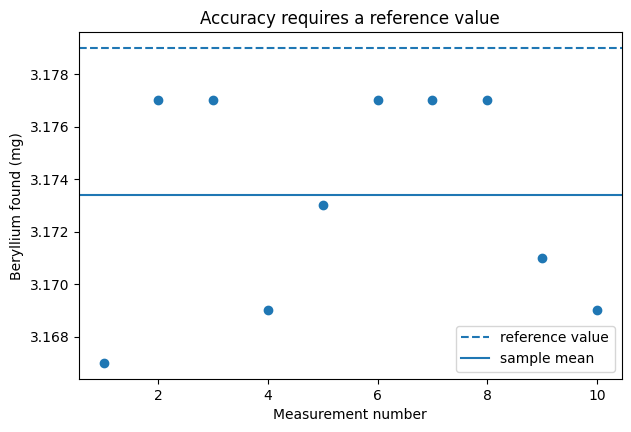

In [19]:
plt.figure(figsize=(7, 4.5))
plt.scatter(np.arange(1, n+1), beryllium_found)
plt.axhline(R, linestyle="--", label="reference value")
plt.axhline(xbar, linestyle="-", label="sample mean")
plt.xlabel("Measurement number")
plt.ylabel("Beryllium found (mg)")
plt.title("Accuracy requires a reference value")
plt.legend()
plt.show()

### Thinking model

```text
precision can be estimated internally from repeated measurements
accuracy requires an external reference
```

Repeated measurements can make the mean very stable, but they cannot prove the method is unbiased.

## 11. Bias is not fixed across all conditions

A measurement process may have different precision and bias depending on:

- level/magnitude of measured value
- material or system being measured
- environmental conditions
- warmup/cache/thermal state
- comparison being made

Below, the bias increases with the level of the true value. A single “accuracy number” would be misleading.

In [ ]:
levels = np.array([10, 20, 40, 80, 160, 320])
true_bias = 0.02 * levels + 1.0
observed_means = levels + true_bias + rng.normal(0, 1.0, size=len(levels))

estimated_biases = observed_means - levels

plt.figure(figsize=(7, 4.5))
plt.plot(levels, estimated_biases, marker="o")
plt.xlabel("Reference value / level")
plt.ylabel("Estimated bias")
plt.title("Bias can be a function of measurement level")
plt.show()

pd.DataFrame({
    "reference_value": levels,
    "observed_mean": observed_means,
    "estimated_bias": estimated_biases
})

### Thinking model

Instead of saying:

```text
this method has standard deviation s and bias b
```

often the better model is:

```text
precision = f(level, material, environment, procedure)
bias      = g(level, material, environment, procedure)
```

## 12. Calibration and certified values

A certified value is not pure truth. It is:

```text
value + uncertainty statement + trust in the calibration process
```

The user of a certified standard usually wants total uncertainty. The certifying lab must understand both:

- random uncertainty / precision
- possible systematic error / upper bound on bias

This is why accuracy statements often sound like:

```text
We believe the error does not exceed ...
```

rather than:

```text
The error is exactly ...
```

## Final checklist for using Chapter 6 in benchmark analysis

When analyzing benchmark data, answer these in order:

```text
1. What exact process generated the numbers?
2. What system/workload/condition was measured?
3. Do all numbers belong to one population?
4. Am I describing individual runs or estimating a mean?
5. Do I need standard deviation, standard error, confidence interval, probability interval, or tolerance interval?
6. Do I have a reference value for accuracy/bias?
7. Could bias vary by level, workload, material, time, or environment?
8. Are systematic errors external to the data being considered?
```

Mapping:

```text
standard deviation  → scatter of individual observations
standard error      → uncertainty of the estimated mean
confidence interval → uncertainty about the population mean
probability interval→ likely range for one future observation
tolerance interval  → range covering a chosen fraction of the population
bias                → population mean - reference value
accuracy            → absence of bias
```